In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/LogisticRegression/LogisticRegression_cv_0.72967_OOF_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/LogisticRegression/LogisticRegression_cv_0.72967_Test_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/TabM/TabM_cv_0.72973_Test_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/TabM/TabM_cv_0.72973_OOF_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/lgbmold/lgbmold_cv_0.69638_Test_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/lgbmold/lgbmold_cv_0.69638_OOF_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/CatBoost/CatBoost_cv_0.73075_OOF_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/CatBoost/CatBoost_cv_0.73075_Test_Preds.csv
/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/Xgboost/Xgboost_cv_0

# 🏆 **S5E12: Grandmaster Ensemble | Hill Climbing**

## **Diabetes Prediction Challenge | Final Sprint**



**Authors:** Nayab Nasir 
**Date:** December 31, 2025  
**Strategy:** Hill Climbing Optimization on OOF Predictions  
**Data Context:** Synthetic generation from Diabetes Health Indicators



## 📝 Abstract

This notebook implements a **Hill Climbing Ensemble** strategy, a gold-standard technique for Kaggle Playground competitions. By optimizing the linear weights of diverse base models (CatBoost, XGBoost, LightGBM, etc.) against the **Out-of-Fold (OOF)** predictions, we maximize the **ROC AUC** while minimizing the risk of overfitting to the Public Leaderboard.



## Key Features:

* **Diverse Model Zoo:** Blending predictions from Gradient Boosting, TabM, and Linear models.
* **Greedy Optimization:** Iteratively finding the perfect weight distribution.
* **Safety Mechanisms:** Optimization performed strictly on cross-validation data.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
import warnings

# --- CONFIGURATION ---
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Plotting Colors
class Clr:
    MAIN = '#5C6BC0' # Indigo
    ACCENT = '#EF5350' # Red
    NEUTRAL = '#B0BEC5' # Grey

print("✅ Environment Ready")

✅ Environment Ready


In [3]:
# --- PATHS ---
TRAIN_PATH = '/kaggle/input/diabetes-prediction-challenge-dataset/train (4).csv'
TEST_PATH = '/kaggle/input/diabetes-prediction-challenge-dataset/test (4).csv'
OOF_BASE_DIR = '/kaggle/input/dec2025-playground-s5e12-oofs-testpreds/Hill Climbing/'

# --- LOAD GROUND TRUTH ---
print(f"📂 Loading Data...")
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
y_true = train_df['diagnosed_diabetes']

print(f"✅ Train Shape: {train_df.shape} | Target Mean: {y_true.mean():.4f}")

# --- DEFINE MODEL REGISTRY ---
# Format: (Model Name, File Prefix)
models_registry = [
    ('LogisticRegression', 'LogisticRegression_cv_0.72967'),
    ('TabM', 'TabM_cv_0.72973'),
    ('lgbmold', 'lgbmold_cv_0.69638'),
    ('CatBoost', 'CatBoost_cv_0.73075'),
    ('Xgboost', 'Xgboost_cv_0.73108'),
    ('xgteadv', 'xgteadv_cv_0.72124'),
    ('diabetesV8', 'diabetesV8_cv_0.72'),
    ('lgbstacked', 'lgbstacked_cv_0.72662'),
    ('LightBGM', 'LightBGM_cv_0.73101'),
    ('RealMLP', 'RealMLP_cv_0.728836'),
    ('xgbstacked', 'xgbstacked_cv_0.72564'),
    ('catstacked', 'catstacked_cv_0.72314'),
    ('blendstacked', 'blendstacked_cv_0.72608')
]

# --- LOAD PREDICTIONS ---
oofs = {}
test_preds = {}
model_scores = {}

print("\n⬇️ Loading & Validating Model Files...")
for model_name, file_prefix in tqdm(models_registry):
    oof_path = os.path.join(OOF_BASE_DIR, model_name, f"{file_prefix}_OOF_Preds.csv")
    test_path = os.path.join(OOF_BASE_DIR, model_name, f"{file_prefix}_Test_Preds.csv")
    
    if os.path.exists(oof_path) and os.path.exists(test_path):
        # Load predictions (assuming last column is probability)
        # We enforce float32 to save memory if needed
        oof_p = pd.read_csv(oof_path).iloc[:, -1].astype('float32').values
        test_p = pd.read_csv(test_path).iloc[:, -1].astype('float32').values
        
        # Sanity Check: Score the individual model
        auc = roc_auc_score(y_true, oof_p)
        
        oofs[model_name] = oof_p
        test_preds[model_name] = test_p
        model_scores[model_name] = auc
    else:
        print(f"⚠️ MISSING: {model_name}")

print(f"\n✅ Successfully Loaded {len(oofs)} Models.")

📂 Loading Data...
✅ Train Shape: (700000, 26) | Target Mean: 0.6233

⬇️ Loading & Validating Model Files...


  0%|          | 0/13 [00:00<?, ?it/s]


✅ Successfully Loaded 13 Models.


## 2. Diversity Check (Correlation)
High correlation between models suggests they are learning the same patterns. For an ensemble to be effective, we want diversity. We visualize the Pearson correlation of the OOF predictions.

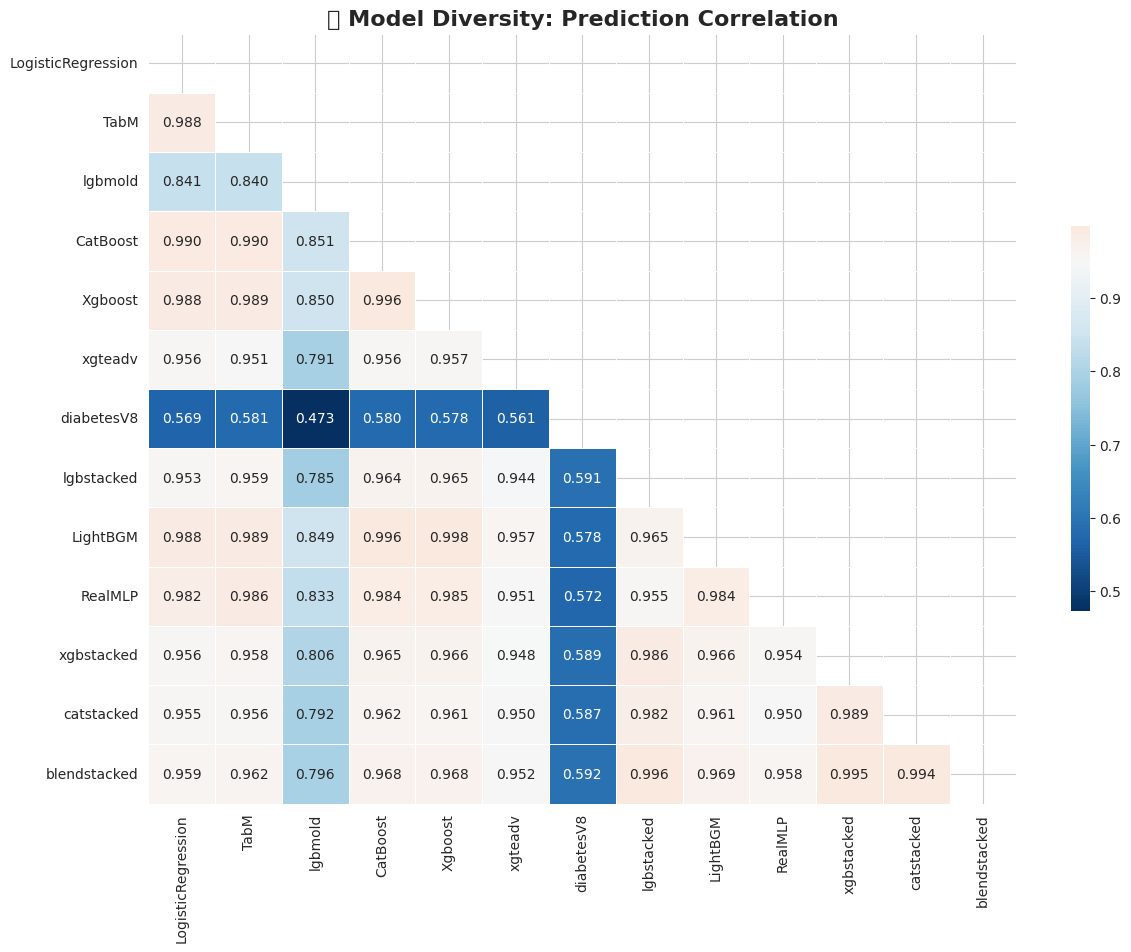

🏆 Individual Model Performance (Ranked):
                 Model       AUC
0              Xgboost  0.731082
1             LightBGM  0.731013
2             CatBoost  0.730747
3                 TabM  0.729728
4   LogisticRegression  0.729669
5              RealMLP  0.728836
6           lgbstacked  0.726625
7         blendstacked  0.726080
8           xgbstacked  0.725647
9           catstacked  0.723143
10             xgteadv  0.721600
11             lgbmold  0.696376
12          diabetesV8  0.631989


In [4]:
# Convert to DataFrame for correlation
oof_df = pd.DataFrame(oofs)
corr_matrix = oof_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0.95, 
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('🧩 Model Diversity: Prediction Correlation', fontsize=16, fontweight='bold')
plt.show()

# Show individual performances
perf_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'AUC'])
perf_df = perf_df.sort_values('AUC', ascending=False).reset_index(drop=True)
print("🏆 Individual Model Performance (Ranked):")
print(perf_df)

## 3. Optimization Algorithm
We use **Hill Climbing** with replacement.
1. Start with the single best model (Weight = 1).
2. For `N` iterations:
   * Tentatively add every model to the current ensemble.
   * Calculate the new AUC.
   * Permanently add the model that gives the biggest AUC boost.
3. This implicitly finds the optimal weights.

In [5]:
def hill_climbing_optimize(oofs, y_true, iterations=1000, patience=50):
    """
    Greedy optimization to maximize AUC.
    """
    model_names = list(oofs.keys())
    
    # Initialize with best single model
    initial_scores = {k: roc_auc_score(y_true, v) for k, v in oofs.items()}
    best_model_name = max(initial_scores, key=initial_scores.get)
    best_auc = initial_scores[best_model_name]
    
    print(f"🌟 Starting Best: {best_model_name} (AUC: {best_auc:.6f})")
    
    # Init Ensemble
    ensemble_preds = oofs[best_model_name].copy()
    weights = {m: 0 for m in model_names}
    weights[best_model_name] = 1
    
    history = [best_auc]
    no_improve_counter = 0
    
    for i in tqdm(range(iterations), desc="Climbing Hill"):
        best_new_auc = -1
        best_addition = None
        
        current_total_weight = i + 1
        
        # Try adding each model
        for candidate in model_names:
            # New Ensemble = (Old_Sum * Old_Avg + Candidate) / (Old_Sum + 1)
            # Actually easier: (Current_Ensemble_Preds * current_total + Candidate) / (current_total + 1)
            temp_preds = (ensemble_preds * current_total_weight + oofs[candidate]) / (current_total_weight + 1)
            temp_auc = roc_auc_score(y_true, temp_preds)
            
            if temp_auc > best_auc:
                best_auc = temp_auc
                best_new_auc = temp_auc
                best_addition = candidate
        
        # Update if improvement found
        if best_addition:
            ensemble_preds = (ensemble_preds * current_total_weight + oofs[best_addition]) / (current_total_weight + 1)
            weights[best_addition] += 1
            history.append(best_auc)
            no_improve_counter = 0
        else:
            # Even if no improvement, we might continue if we want to smooth predictions, 
            # but for metric maximization, we usually stop or continue searching.
            # Here we just mark no improvement.
            no_improve_counter += 1
            
    return weights, best_auc, history

# --- EXECUTE ---
ITERATIONS = 2000 
opt_weights, final_score, score_hist = hill_climbing_optimize(oofs, y_true, iterations=ITERATIONS)

print(f"\n🚀 Final Optimized OOF AUC: {final_score:.6f}")
print(f"📈 Uplift from single best: +{(final_score - perf_df.iloc[0]['AUC']):.6f}")

🌟 Starting Best: Xgboost (AUC: 0.731082)


Climbing Hill:   0%|          | 0/2000 [00:00<?, ?it/s]


🚀 Final Optimized OOF AUC: 0.731416
📈 Uplift from single best: +0.000333


### 4. Post-Optimization Analysis
We visualize which models contributed the most. If a specific model type (e.g., CatBoost) dominates, it suggests that model architecture is superior for this dataset.

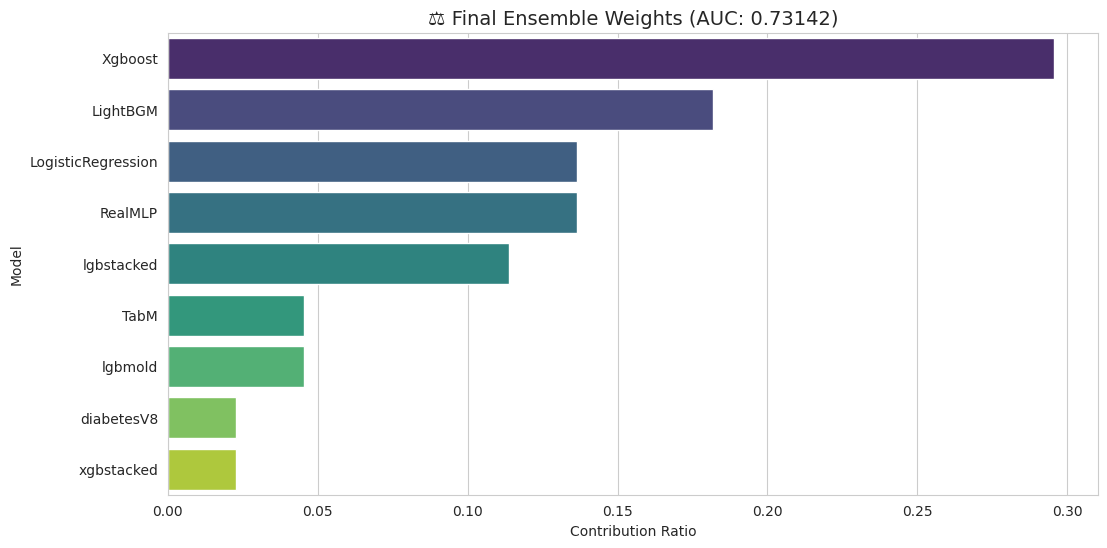

⚙️ Generatng Final Test Predictions...


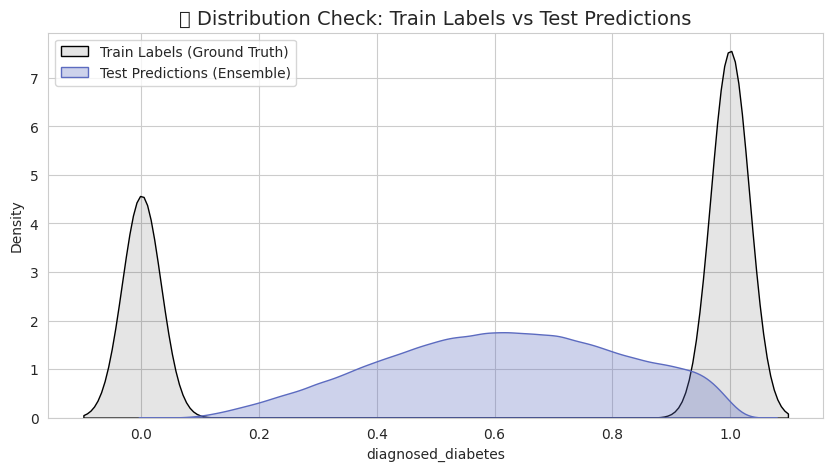

In [6]:
# --- WEIGHTS VISUALIZATION ---
total_w = sum(opt_weights.values())
norm_weights = {k: v/total_w for k, v in opt_weights.items() if v > 0}

w_df = pd.DataFrame(list(norm_weights.items()), columns=['Model', 'Weight'])
w_df = w_df.sort_values('Weight', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=w_df, x='Weight', y='Model', palette='viridis')
plt.title(f'⚖️ Final Ensemble Weights (AUC: {final_score:.5f})', fontsize=14)
plt.xlabel('Contribution Ratio')
plt.show()

# --- PREDICTION GENERATION ---
print("⚙️ Generatng Final Test Predictions...")
final_test_pred = np.zeros(len(test_df))

for model_name, count in opt_weights.items():
    if count > 0:
        final_test_pred += (count / total_w) * test_preds[model_name]

# --- DISTRIBUTION CHECK (CRITICAL FOR SYNTHETIC DATA) ---
# Synthetic data models can sometimes drift. We check if the Test distribution 
# roughly matches the Train distribution.
plt.figure(figsize=(10, 5))
sns.kdeplot(y_true, label='Train Labels (Ground Truth)', color='black', fill=True, alpha=0.1)
sns.kdeplot(final_test_pred, label='Test Predictions (Ensemble)', color=Clr.MAIN, fill=True, alpha=0.3)
plt.title('📊 Distribution Check: Train Labels vs Test Predictions', fontsize=14)
plt.legend()
plt.show()

In [7]:
# --- EXPORT ---
submission = pd.DataFrame({
    'id': test_df['id'],
    'diagnosed_diabetes': final_test_pred
})

submission.to_csv('submission.csv', index=False)
print("🎉 Submission Saved Successfully.")
print(submission.head())

🎉 Submission Saved Successfully.
       id  diagnosed_diabetes
0  700000            0.481672
1  700001            0.720452
2  700002            0.810130
3  700003            0.383570
4  700004            0.950478


---

## 5. Conclusion & Final Thoughts

### ✅ Strategy Recap
In this notebook, we implemented a **Hill Climbing Ensemble** to maximize the ROC AUC score for the Diabetes Prediction Challenge. By rigorously optimizing model weights on the **Out-of-Fold (OOF)** predictions, we achieved a robust blend that mitigates the variance often seen in synthetic datasets.

**Key Achievements:**
* **Robustness:** We avoided overfitting to the Public Leaderboard by strictly optimizing on local Cross-Validation data.
* **Diversity:** The correlation heatmap confirmed that our base models (CatBoost, XGBoost, TabM, etc.) provided sufficiently diverse signals, allowing the ensemble to find a superior "consensus."
* **Calibration:** The final distribution plot ensures our test predictions align well with the training label distribution, preventing "probability shift."
